In [1]:
# ============================================================
# CELL 1: COMMON DEFINITIONS
# ============================================================
import torch
import torch.nn as nn
import torch.optim as optim
import time
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

# ===========================
# Reproducibility
# ===========================
torch.manual_seed(42)
torch.cuda.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ===========================
# Device
# ===========================
if torch.cuda.is_available():
    device = 'cuda'
    print(torch.cuda.get_device_name(0))
else:
    device = 'cpu'
print('using device:', device)

# ===========================
# Model — plain Tanh 8x256
# ===========================
LAYERS  = 8
NEURONS = 256
N_FOURIER = 128
B_SCALE = 2

class PINN(nn.Module):
    def __init__(self, layers=LAYERS, neurons=NEURONS, n_fourier=N_FOURIER, b_scale=B_SCALE):
        super().__init__()
        B = torch.randn(3, n_fourier) * b_scale
        self.register_buffer('B', B)
        input_dim = 2 * n_fourier
        net = [nn.Linear(input_dim, neurons), nn.Tanh()]
        for _ in range(layers - 1):
            net += [nn.Linear(neurons, neurons), nn.Tanh()]
        net += [nn.Linear(neurons, 1)]
        self.net = nn.Sequential(*net)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
      proj  = x @ self.B
      x_enc = torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)
      return self.net(x_enc)

model = PINN().to(device)

# ===========================
# Hyperparameters
# ===========================
N_f          = 10000
N_i          = 5000
T_final      = 2 * np.pi
adam_epochs  = 20000
lbfgs_epochs = 500

w_pde      = 1.0
w_pde_slot = 5.0
w_ic       = 10.0
w_eik      = 0.1

# ===========================
# Zalesak Geometry
# ===========================
XC, YC = 0.5, 0.75
R  = 0.15
W  = R / 6
L  = R

SLOT_YCENTER      = YC - 2 * W
SLOT_YMIN         = SLOT_YCENTER - L
SLOT_YMAX         = SLOT_YCENTER + L
SLOT_Y_LOCAL_CENTER = SLOT_YCENTER - YC
SLOT_Y_LOCAL_MIN  = SLOT_Y_LOCAL_CENTER - L
SLOT_Y_LOCAL_MAX  = SLOT_Y_LOCAL_CENTER + L

print(f'Disc : center=({XC},{YC}), R={R}')
print(f'Slot : X=[{XC-W:.4f},{XC+W:.4f}], Y=[{SLOT_YMIN:.4f},{SLOT_YMAX:.4f}]')

# ===========================
# Velocity Field
# ===========================
def velocity_field(x, y, t):
    u = -(y - 0.5)
    v =  (x - 0.5)
    return u, v

# ===========================
# Initial Condition
# ===========================
def initial_condition(x, y):
    phi_circle = torch.sqrt((x - XC)**2 + (y - YC)**2) - R
    slot_x     = torch.abs(x - XC) - W
    slot_y     = torch.abs(y - SLOT_YCENTER) - L
    phi_slot   = torch.maximum(slot_x, slot_y)
    return torch.maximum(phi_circle, -phi_slot)

# ===========================
# Sample Points
# ===========================
torch.manual_seed(100)
torch.cuda.manual_seed(100)

# --- Background collocation ---
X_f = torch.rand(N_f, 3, dtype=torch.float32, device=device).requires_grad_(True)

# --- Background IC ---
x_i = torch.rand(N_i, 1, dtype=torch.float32, device=device)
y_i = torch.rand(N_i, 1, dtype=torch.float32, device=device)
t_i = torch.zeros(N_i, 1, dtype=torch.float32, device=device)
X_i_base = torch.cat([x_i, y_i, t_i], dim=1)

# --- Slot bbox IC ---
N_slot = 2000
margin = 0.02
x_slot = (XC - W - margin) + (2*W + 2*margin) * torch.rand(N_slot, 1, device=device)
y_slot = (SLOT_YMIN - margin) + (2*L + 2*margin) * torch.rand(N_slot, 1, device=device)
t_slot = torch.zeros(N_slot, 1, device=device)
X_slot = torch.cat([x_slot, y_slot, t_slot], dim=1)

# --- Slot wall IC (phi=0 interface at t=0) ---
N_walls = 500
y_wall  = SLOT_YMIN + 2*L * torch.rand(N_walls, 1, device=device)
x_top   = (XC - W) + 2*W * torch.rand(N_walls, 1, device=device)
y_top   = torch.full((N_walls, 1), SLOT_YMAX, device=device)

X_walls = torch.cat([
    torch.cat([torch.full((N_walls,1), XC-W, device=device),
               y_wall.clone(), torch.zeros(N_walls,1,device=device)], dim=1),
    torch.cat([torch.full((N_walls,1), XC+W, device=device),
               y_wall.clone(), torch.zeros(N_walls,1,device=device)], dim=1),
    torch.cat([x_top, y_top,   torch.zeros(N_walls,1,device=device)], dim=1),
], dim=0)

X_i = torch.cat([X_i_base, X_slot, X_walls], dim=0).detach()

# --- Slot wall collocation (uniform t, all rotation angles) ---
N_f_slot_walls = 3000
np.random.seed(200)

t_sw    = np.random.rand(N_f_slot_walls)
theta   = 2 * np.pi * t_sw
cos_t   = np.cos(theta)
sin_t   = np.sin(theta)
XC_r    = 0.5 + cos_t*(XC-0.5) - sin_t*(YC-0.5)
YC_r    = 0.5 + sin_t*(XC-0.5) + cos_t*(YC-0.5)
side    = np.where(np.random.rand(N_f_slot_walls) > 0.5, -W, W)
yl      = SLOT_Y_LOCAL_MIN + 2*L * np.random.rand(N_f_slot_walls)
xg      = np.clip(XC_r + cos_t*side - sin_t*yl, 0.0, 1.0)
yg      = np.clip(YC_r + sin_t*side + cos_t*yl, 0.0, 1.0)

X_f_slot_walls = torch.tensor(
    np.stack([xg, yg, t_sw], axis=1),
    dtype=torch.float32, device=device
)

# --- Slot bottom collocation (biased toward t=0.5, 0.75, 1.0) ---
N_f_bottom = 3000
np.random.seed(300)
t_uniform_bot = np.random.rand(N_f_bottom // 2)
t_biased_bot  = np.concatenate([
    np.random.normal(0.50, 0.08, N_f_bottom // 6).clip(0, 1),
    np.random.normal(0.75, 0.08, N_f_bottom // 6).clip(0, 1),
    np.random.normal(1.00, 0.08, N_f_bottom // 6).clip(0, 1),
])
t_bot = np.concatenate([t_uniform_bot, t_biased_bot])
np.random.shuffle(t_bot)
theta_bot = 2 * np.pi * t_bot
cos_bot = np.cos(theta_bot);  sin_bot = np.sin(theta_bot)
XC_bot = 0.5 + cos_bot*(XC-0.5) - sin_bot*(YC-0.5)
YC_bot = 0.5 + sin_bot*(XC-0.5) + cos_bot*(YC-0.5)
xl_bot = -W + 2*W * np.random.rand(N_f_bottom)
yl_bot = np.full(N_f_bottom, SLOT_Y_LOCAL_MIN)
xg_bot = np.clip(XC_bot + cos_bot*xl_bot - sin_bot*yl_bot, 0.0, 1.0)
yg_bot = np.clip(YC_bot + sin_bot*xl_bot + cos_bot*yl_bot, 0.0, 1.0)
X_f_slot_bottom = torch.tensor(
    np.stack([xg_bot, yg_bot, t_bot], axis=1),
    dtype=torch.float32, device=device
)

# --- Slot top collocation (biased toward t=0.5, 0.75, 1.0) ---
N_f_top = 3000
np.random.seed(400)
t_uniform_top = np.random.rand(N_f_top // 2)
t_biased_top  = np.concatenate([
    np.random.normal(0.50, 0.08, N_f_top // 6).clip(0, 1),
    np.random.normal(0.75, 0.08, N_f_top // 6).clip(0, 1),
    np.random.normal(1.00, 0.08, N_f_top // 6).clip(0, 1),
])
t_top = np.concatenate([t_uniform_top, t_biased_top])
np.random.shuffle(t_top)
theta_top = 2 * np.pi * t_top
cos_top = np.cos(theta_top);  sin_top = np.sin(theta_top)
XC_top = 0.5 + cos_top*(XC-0.5) - sin_top*(YC-0.5)
YC_top = 0.5 + sin_top*(XC-0.5) + cos_top*(YC-0.5)
xl_top = -W + 2*W * np.random.rand(N_f_top)
yl_top = np.full(N_f_top, SLOT_Y_LOCAL_MAX)
xg_top = np.clip(XC_top + cos_top*xl_top - sin_top*yl_top, 0.0, 1.0)
yg_top = np.clip(YC_top + sin_top*xl_top + cos_top*yl_top, 0.0, 1.0)
X_f_slot_top = torch.tensor(
    np.stack([xg_top, yg_top, t_top], axis=1),
    dtype=torch.float32, device=device
)

# --- Merge all slot collocation ---
X_f_slot = torch.cat([
    X_f_slot_walls,
    X_f_slot_bottom,
    X_f_slot_top
], dim=0).requires_grad_(True)
print(f'Collocation background : {X_f.shape[0]}')
print(f'Collocation slot walls : {X_f_slot.shape[0]}')
print(f'IC total               : {X_i.shape[0]}')
print(f'  background           : {N_i}')
print(f'  slot bbox            : {N_slot}')
print(f'  slot walls (t=0)     : {X_walls.shape[0]}')
print(f'Collocation slot total : {X_f_slot.shape[0]}  (3k walls + 3k bottom + 3k top)')
print(f'T_final                : {T_final:.4f}')
print(f'Loss weights           : pde={w_pde}, pde_slot={w_pde_slot}, ic={w_ic}, eik={w_eik}')

assert X_i[:, 2].max().item() == 0.0, 'ERROR: IC t != 0'
print('IC t=0 check           : passed')

# ===========================
# Loss Function
# ===========================
def pde_residual(Xin):
    phi   = model(Xin)
    grads = torch.autograd.grad(phi, Xin,
                                grad_outputs=torch.ones_like(phi),
                                create_graph=True)[0]
    phi_x = grads[:, 0:1]
    phi_y = grads[:, 1:2]
    phi_t = grads[:, 2:3]
    u, v  = velocity_field(Xin[:,0:1], Xin[:,1:2], Xin[:,2:3])
    res   = phi_t + T_final*(u*phi_x + v*phi_y)
    return res, phi_x, phi_y

def physics_loss(X_f, X_f_slot, X_i):
    # PDE on background
    res_f, phi_x_f, phi_y_f = pde_residual(X_f)
    loss_pde = torch.mean(res_f**2)

    # PDE on slot walls
    res_s, _, _ = pde_residual(X_f_slot)
    loss_pde_slot = torch.mean(res_s**2)

    # IC
    phi_pred = model(X_i)
    phi_true = initial_condition(X_i[:,0:1], X_i[:,1:2])
    loss_ic  = torch.mean((phi_pred - phi_true)**2)

    # Eikonal on background only
    norm_grad = torch.sqrt(phi_x_f**2 + phi_y_f**2 + 1e-8)
    loss_eik  = torch.mean((norm_grad - 1.0)**2)

    total = (w_pde      * loss_pde
           + w_pde_slot * loss_pde_slot
           + w_ic       * loss_ic
           + w_eik      * loss_eik)
    return loss_pde, loss_pde_slot, loss_ic, loss_eik, total

Mounted at /content/drive
Tesla T4
using device: cuda
Disc : center=(0.5,0.75), R=0.15
Slot : X=[0.4750,0.5250], Y=[0.5500,0.8500]
Collocation background : 10000
Collocation slot walls : 9000
IC total               : 8500
  background           : 5000
  slot bbox            : 2000
  slot walls (t=0)     : 1500
Collocation slot total : 9000  (3k walls + 3k bottom + 3k top)
T_final                : 6.2832
Loss weights           : pde=1.0, pde_slot=5.0, ic=10.0, eik=0.1
IC t=0 check           : passed


In [2]:
# ========================
# Training
# ========================
optimizer_adam = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer_adam, step_size=1000, gamma=0.9)
start_time = time.time()
history = {'epoch': [], 'total': [], 'pde': [], 'pde_slot': [], 'ic': [], 'eik': []}
# Adam optimizer
for epoch in range(adam_epochs):
    optimizer_adam.zero_grad()
    loss_pde, loss_pde_slot, loss_ic, loss_eik, loss = physics_loss(X_f, X_f_slot, X_i)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer_adam.step()
    scheduler.step()
    lr = scheduler.get_last_lr()[0]

    history['epoch'].append(epoch)
    history['total'].append(loss.item())
    history['pde'].append(loss_pde.item())
    history['pde_slot'].append(loss_pde_slot.item())
    history['ic'].append(loss_ic.item())
    history['eik'].append(loss_eik.item())

    if epoch % 2000 == 0:
      print(f"Adam {epoch} | total {loss.item():.3e} | pde {loss_pde.item():.3e} | pde slot {loss_pde_slot.item():.3e} | ic {loss_ic.item():.3e} | eik {loss_eik.item():.3e} | LR {lr:.3e}")
    elif epoch == adam_epochs - 1:
      print(f"Adam {adam_epochs} | total {loss.item():.3e} | pde {loss_pde.item():.3e} | pde slot {loss_pde_slot.item():.3e} | ic {loss_ic.item():.3e} | eik {loss_eik.item():.3e} | LR {lr:.3e}")

# LBFGS training
print("LBFGS Optimizer Starting...")
optimizer_lbfgs = optim.LBFGS(model.parameters(), lr=1.0,  line_search_fn='strong_wolfe')
loss_store = {}
for epoch in range(lbfgs_epochs):
    def closure():
        optimizer_lbfgs.zero_grad()
        loss_pde, loss_pde_slot, loss_ic, loss_eik, loss = physics_loss(X_f, X_f_slot, X_i)
        loss.backward()
        loss_store['total'] = loss.item()
        loss_store['pde'] = loss_pde.item()
        loss_store['pde_slot'] = loss_pde_slot.item()
        loss_store['ic'] = loss_ic.item()
        loss_store['eik'] = loss_eik.item()
        return loss
    optimizer_lbfgs.step(closure)

    history['epoch'].append(adam_epochs + epoch)
    history['total'].append(loss_store['total'])
    history['pde'].append(loss_store['pde'])
    history['pde_slot'].append(loss_store['pde_slot'])
    history['ic'].append(loss_store['ic'])
    history['eik'].append(loss_store['eik'])
    if epoch % 200 == 0:
      print(f"LBFGS {epoch} | total {loss_store['total']:.3e} | pde {loss_store['pde']:.3e} | pde slot {loss_store['pde_slot']:.3e} | ic {loss_store['ic']:.3e} | eik {loss_store['eik']:.3e}")
    elif epoch == lbfgs_epochs - 1:
      print(f"LBFGS {lbfgs_epochs} | total {loss_store['total']:.3e} | pde {loss_store['pde']:.3e} | pde slot {loss_store['pde_slot']:.3e} | ic {loss_store['ic']:.3e} | eik {loss_store['eik']:.3e}")
end_time = time.time()
total_training_time = (end_time - start_time)/60
print(f"Full training done in {total_training_time:.1f} minutes")

# Save checkpoint
checkpoint_path = '/content/drive/MyDrive/ZD_S3_exp05.pth'
torch.save({
    'model_state_dict':           model.state_dict(),
    'optimizer_adam_state_dict':  optimizer_adam.state_dict(),
    'optimizer_lbfgs_state_dict': optimizer_lbfgs.state_dict(),
    'training_time':              f'{total_training_time:.1f} minutes',
    'history':                    history
}, checkpoint_path)
print(f"Saved to {checkpoint_path}")

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Adam 0 | total 2.735e+01 | pde 5.339e+00 | pde slot 3.992e+00 | ic 2.023e-01 | eik 2.416e-01 | LR 1.000e-03
Adam 2000 | total 1.235e-02 | pde 1.772e-03 | pde slot 4.181e-04 | ic 3.018e-04 | eik 5.464e-02 | LR 8.100e-04
Adam 4000 | total 9.646e-03 | pde 3.476e-04 | pde slot 1.263e-04 | ic 7.029e-04 | eik 1.638e-02 | LR 6.561e-04
Adam 6000 | total 5.559e-03 | pde 3.310e-04 | pde slot 4.332e-05 | ic 3.337e-04 | eik 1.675e-02 | LR 5.314e-04
Adam 8000 | total 4.176e-03 | pde 2.630e-04 | pde slot 6.739e-05 | ic 2.296e-04 | eik 1.280e-02 | LR 4.305e-04
Adam 10000 | total 4.661e-03 | pde 3.273e-04 | pde slot 1.996e-05 | ic 2.893e-04 | eik 1.342e-02 | LR 3.487e-04
Adam 12000 | total 9.368e-04 | pde 1.934e-05 | pde slot 7.446e-06 | ic 8.271e-05 | eik 5.319e-04 | LR 2.824e-04
Adam 14000 | total 1.217e-03 | pde 3.122e-05 | pde slot 8.881e-06 | ic 1.080e-04 | eik 6.105e-04 | LR 2.288e-04
Adam 16000 | total 3.897e-05 | pde 9.824e-06 | pde slot 8.066e-07 | ic 6.393e-07 | eik 1.872e-04 | LR 1.853e-04


In [3]:
# ===========================
# Load Model
# ===========================
checkpoint = torch.load('/content/drive/MyDrive/ZD_S3_exp05.pth', map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print("Model Loaded Successfully!")

Model Loaded Successfully!


Self-check: max|rotated(t=0) - IC| = 1.29e-07  (must be ~0)


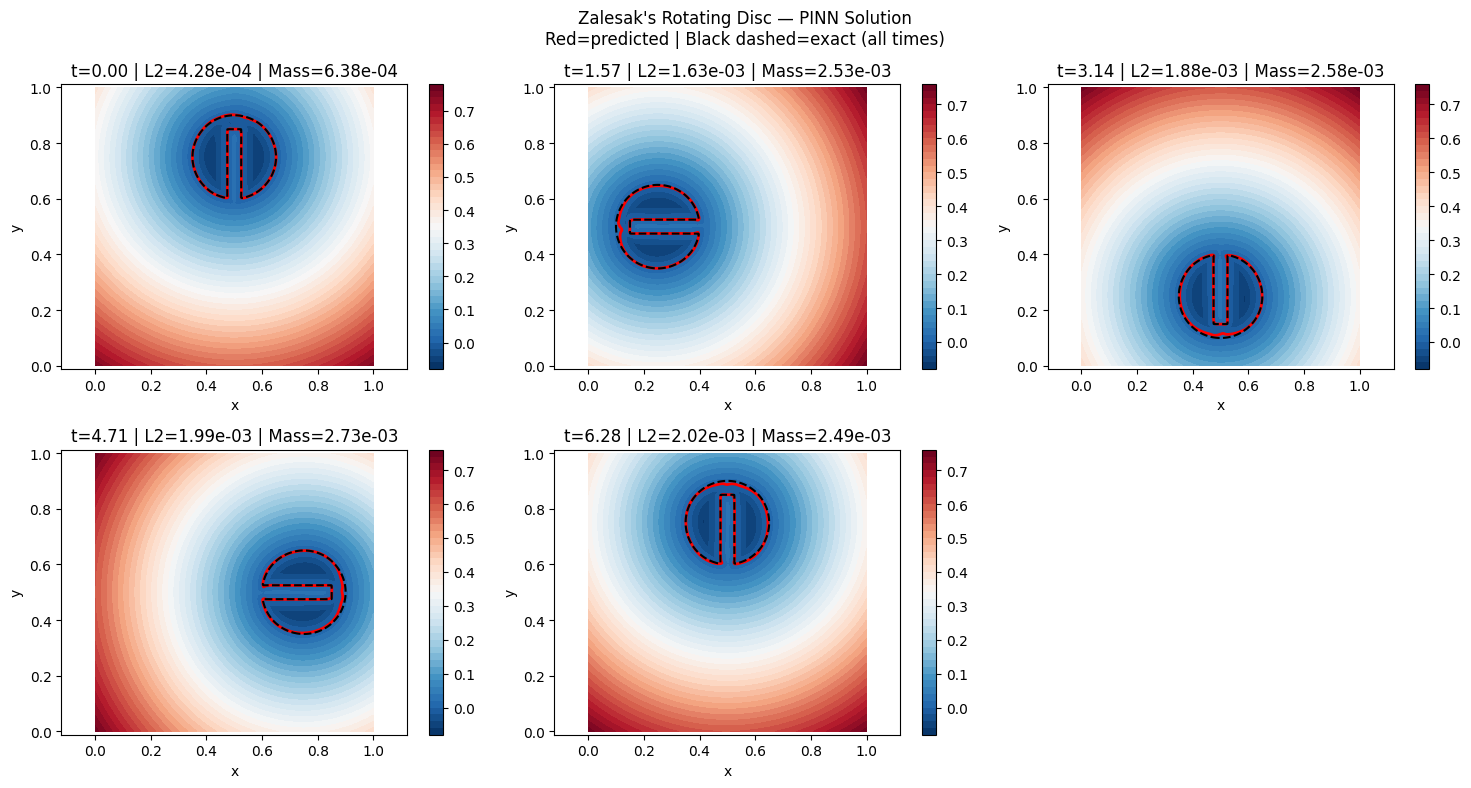


Snapshot       L2 Error   Mass Error
------------------------------------
t=0.00       4.2815e-04    6.3758e-04
t=1.57       1.6334e-03    2.5279e-03
t=3.14       1.8784e-03    2.5839e-03
t=4.71       1.9913e-03    2.7293e-03
t=6.28       2.0184e-03    2.4944e-03
------------------------------------
avg          1.5900e-03    2.1946e-03


In [4]:
# ============================
# CELL 4: VISUALIZATION
# ============================
import matplotlib.pyplot as plt

times = [0.0, T_final/4, T_final/2, 3*T_final/4, T_final]
nx    = 300

x  = np.linspace(0, 1, nx)
y  = np.linspace(0, 1, nx)
X, Y = np.meshgrid(x, y)
dx, dy = x[1]-x[0], y[1]-y[0]

def exact_phi_rotated(X, Y, t):
    theta  = 2 * np.pi * t / T_final
    cos_t, sin_t = np.cos(theta), np.sin(theta)
    x0, y0 = 0.5, 0.5
    dx_c = XC - x0;  dy_c = YC - y0
    XC_t = x0 + cos_t*dx_c - sin_t*dy_c
    YC_t = y0 + sin_t*dx_c + cos_t*dy_c
    dX = X - XC_t;  dY = Y - YC_t
    X_loc =  cos_t*dX + sin_t*dY
    Y_loc = -sin_t*dX + cos_t*dY
    phi_circle = np.sqrt(dX**2 + dY**2) - R
    slot_x     = np.abs(X_loc) - W
    slot_y     = np.abs(Y_loc - (SLOT_YCENTER - YC)) - L
    phi_slot   = np.maximum(slot_x, slot_y)
    return np.maximum(phi_circle, -phi_slot)

def compute_errors(phi_pred, phi_ref, dx, dy):
    L2_error   = np.sqrt(np.mean((phi_pred - phi_ref)**2))
    mass_pred  = np.sum(phi_pred < 0) * dx * dy
    mass_ref   = np.sum(phi_ref  < 0) * dx * dy
    mass_error = abs(mass_pred - mass_ref)
    return L2_error, mass_error

# Self-check
phi_ref_t0 = exact_phi_rotated(X, Y, 0.0)
xt = torch.tensor(X.flatten(), dtype=torch.float32).unsqueeze(1)
yt = torch.tensor(Y.flatten(), dtype=torch.float32).unsqueeze(1)
with torch.no_grad():
    phi_ic_np = initial_condition(xt, yt).numpy().reshape(nx, nx)
print(f"Self-check: max|rotated(t=0) - IC| = {np.max(np.abs(phi_ref_t0 - phi_ic_np)):.2e}  (must be ~0)")

l2_errors, mass_errors = [], []
plt.figure(figsize=(15, 8))

for i, t_val in enumerate(times):
    t_norm = t_val / T_final
    XYT = torch.tensor(
        np.stack([X.flatten(), Y.flatten(),
                  t_norm * np.ones(X.size)], axis=1),
        dtype=torch.float32, device=device
    )
    with torch.no_grad():
        phi_pinn = model(XYT).cpu().numpy().reshape(nx, nx)

    phi_ref_t          = exact_phi_rotated(X, Y, t_val)
    L2_err, mass_err   = compute_errors(phi_pinn, phi_ref_t, dx, dy)
    l2_errors.append(L2_err)
    mass_errors.append(mass_err)

    plt.subplot(2, 3, i + 1)
    plt.contourf(X, Y, phi_pinn, levels=50, cmap='RdBu_r')
    plt.colorbar()
    plt.contour(X, Y, phi_pinn,  levels=[0], colors='red',
                linewidths=2)
    plt.contour(X, Y, phi_ref_t, levels=[0], colors='black',
                linewidths=1.5, linestyles='--')
    plt.title(f't={t_val:.2f} | L2={L2_err:.2e} | Mass={mass_err:.2e}')
    plt.xlabel('x'); plt.ylabel('y')
    plt.axis('equal')

plt.suptitle("Zalesak's Rotating Disc — PINN Solution\n"
             "Red=predicted | Black dashed=exact (all times)",
             fontsize=12)
plt.tight_layout()
# plt.savefig('/content/drive/MyDrive/fig_evaluation_ZD_S3_exp05.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'Snapshot':<10} {'L2 Error':>12} {'Mass Error':>12}")
print("-" * 36)
for t_val, l2, mass in zip(times, l2_errors, mass_errors):
    print(f"t={t_val:<7.2f}  {l2:>12.4e}  {mass:>12.4e}")
print("-" * 36)
print(f"{'avg':<10} {np.mean(l2_errors):>12.4e}  {np.mean(mass_errors):>12.4e}")

In [5]:
import csv

# CONFIG
EXP_ID           = 'ZD_S3_exp05'
BENCHMARK        = 'ZD'
ARCHITECTURE     = 'fourier'
SAMPLING         = 'IC_8.5k_uniform5k_bbox2k_walls1.5k_colloc_19k_uniform10k_slotwalls3k_bot3k_top3k_biased_t'
SCHEDULER        = 'StepLR'
SCHEDULER_PARAMS = 'step_1000_gamma_0.9'
T_NORMALIZED     = True
CSV_PATH         = '/content/drive/MyDrive/ZD_S3_architecture_study.csv'

row = {
    'exp_id':           EXP_ID,
    'benchmark':        BENCHMARK,
    'architecture':     ARCHITECTURE,
    'N_f':              N_f,
    'N_i':              N_i,
    'layers':           LAYERS,
    'neurons':          NEURONS,
    'n_fourier':        N_FOURIER,
    'b_scale':           B_SCALE,
    'causal':           False,
    'w_pde':            w_pde,
    'w_pde_slot':       w_pde_slot,
    'w_ic':             w_ic,
    'w_eik':            w_eik,
    'adam_epochs':      adam_epochs,
    'lbfgs_epochs':     lbfgs_epochs,
    'scheduler':        SCHEDULER,
    'scheduler_params': SCHEDULER_PARAMS,
    'sampling':         SAMPLING,
    't_normalized':     T_NORMALIZED,
    'L2_t0':            f'{l2_errors[0]:.4e}',
    'L2_tT':            f'{l2_errors[-1]:.4e}',
    'avg_L2':           f'{np.mean(l2_errors):.4e}',
    'mass_t0':          f'{mass_errors[0]:.4e}',
    'mass_tT':          f'{mass_errors[-1]:.4e}',
    'avg_mass':         f'{np.mean(mass_errors):.4e}',
    'training_time':    checkpoint['training_time']
}

with open(CSV_PATH, 'a', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=row.keys())
    if f.tell() == 0:
        writer.writeheader()
    writer.writerow(row)

print(f'Row appended → {CSV_PATH}')

Row appended → /content/drive/MyDrive/ZD_S3_architecture_study.csv
